# Step 3 — Time-Series CV Setup

**Project:** VNKT Winter Fog Forecasting (STW7085CEM Task 1)

This notebook is a thin wrapper around `scripts/cv_splits.py`. All logic lives in the script; this notebook only imports, runs, and visualises.

**What this step does**

1. Loads the Step 2 modelling table (`data/processed/vnkt_modelling_table.parquet`)
2. Splits off the 2025-26 holdout season (never enters CV)
3. Builds 8 forward-chaining CV folds with a growing training window
4. For each fold, fits a median-imputer + StandardScaler on training data only (no leakage)
5. Writes a JSON manifest documenting every split for the paper's audit trail
6. Generates a Gantt-style fold-structure visualisation

**Design decisions** (full rationale in the script's module docstring):

- 2025-26 reserved as strict holdout (2 Diversions days, small but temporally valid)
- 2015-16 partial season combined with 2016-17 to form Fold 1's training set
- `night_obs_count` excluded from features (data-quality artefact, not weather signal)
- 19 features fed to models; impute+scale fitted per fold on training data only

In [2]:
import sys
from pathlib import Path

# Make scripts/ importable when running from notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

from cv_splits import (
    HOLDOUT_SEASON,
    INITIAL_TRAINING_SEASONS,
    FEATURE_COLUMNS,
    TARGET_REGRESSION,
    TARGET_CLASSIFICATION,
    CLASS_NAMES,
    load_modelling_table,
    split_holdout,
    forward_chaining_folds,
    iter_prepared_folds,
    find_constant_features,
    summarise_folds,
    save_manifest,
)

print(f'Project root: {PROJECT_ROOT}')
print(f'Holdout season: {HOLDOUT_SEASON}')
print(f'Initial training seasons: {INITIAL_TRAINING_SEASONS}')
print(f'Features ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}')

Project root: /home/saggy/Desktop/advanced-ml-assignement
Holdout season: 2025-26
Initial training seasons: ['2015-16', '2016-17']
Features (19): ['sunset_tempc', 'sunset_dewpoint_depr_c', 'sunset_pressure_hpa', 'sunset_wind_speed_ms', 'sunset_visibility_m', 'predawn_tempc', 'predawn_dewpoint_depr_c', 'predawn_pressure_hpa', 'overnight_temp_drop_c', 'overnight_dewpoint_depr_drop_c', 'overnight_pressure_change_hpa', 'night_mean_wind_speed_ms', 'night_calm_fraction', 'night_mean_sky_cover', 'night_clear_fraction', 'night_mist_observed', 'night_fog_observed', 'doy_sin', 'doy_cos']


## 1. Load modelling table and split off the holdout

In [3]:
df = load_modelling_table()
train_pool, holdout = split_holdout(df)

print('\nTrain pool seasons:')
print(train_pool['season'].value_counts().sort_index().to_string())
print(f"\nHoldout {HOLDOUT_SEASON}: {len(holdout)} rows")
print(f"Holdout class counts: "
      f"Normal={int((holdout[TARGET_CLASSIFICATION]==0).sum())}, "
      f"Delays={int((holdout[TARGET_CLASSIFICATION]==1).sum())}, "
      f"Diversions={int((holdout[TARGET_CLASSIFICATION]==2).sum())}")

[20:31:31] INFO  Loading modelling table: /home/saggy/Desktop/advanced-ml-assignement/data/processed/vnkt_modelling_table.parquet
[20:31:32] INFO    rows=1561  seasons=11  date_range=2016-01-02 -> 2026-02-28
[20:31:32] INFO  Holdout season 2025-26: 151 rows  |  train pool: 1410 rows across 10 seasons



Train pool seasons:
season
2015-16     59
2016-17    145
2017-18    151
2018-19    149
2019-20    152
2020-21    150
2021-22    150
2022-23    151
2023-24    152
2024-25    151

Holdout 2025-26: 151 rows
Holdout class counts: Normal=116, Delays=33, Diversions=2


## 2. Build forward-chaining folds and inspect

In [4]:
folds = forward_chaining_folds(train_pool)
summary = summarise_folds(train_pool, folds)
summary

[20:31:32] INFO  Built 8 forward-chaining folds


,fold,train_seasons,test_season,train_n,test_n,train_Normal,train_Delays,train_Div,test_Normal,test_Delays,test_Div,train_end,test_start
0,1,2015-16 + 2016-17,2017-18,204,151,91,97,16,89,54,8,2017-02-28,2017-10-01
1,2,2015-16 .. 2017-18,2018-19,355,149,180,151,24,80,64,5,2018-02-28,2018-10-01
2,3,2015-16 .. 2018-19,2019-20,504,152,260,215,29,99,51,2,2019-02-28,2019-10-01
3,4,2015-16 .. 2019-20,2020-21,656,150,359,266,31,131,17,2,2020-02-29,2020-10-01
4,5,2015-16 .. 2020-21,2021-22,806,150,490,283,33,117,29,4,2021-02-28,2021-10-01
5,6,2015-16 .. 2021-22,2022-23,956,151,607,312,37,131,17,3,2022-02-28,2022-10-01
6,7,2015-16 .. 2022-23,2023-24,1107,152,738,329,40,143,8,1,2023-02-28,2023-10-01
7,8,2015-16 .. 2023-24,2024-25,1259,151,881,337,41,132,19,0,2024-02-29,2024-10-01


## 3. End-to-end sanity check on prepared folds

For every fold, confirm:
- No NaN remains in `X_train` or `X_test` after median imputation
- Feature matrices have the expected shape (19 columns)
- `X_train` is zero-mean, unit-variance after standardisation (fitted on train only)
- `X_test` mean/std are close to but not exactly 0/1 (drift signal — useful diagnostic for later steps)

The `constant_features` column names any feature whose training-fold std is zero. A zero-variance column is harmless (sklearn safe-divides; downstream RF and GP-ARD both deweight such features automatically) but worth surfacing as a data-property finding.

In [5]:
checks = []
for prepared in iter_prepared_folds(train_pool):
    row = {
        'fold': prepared.spec.fold_id,
        'X_train_shape': prepared.X_train.shape,
        'X_test_shape': prepared.X_test.shape,
        'X_train_nan': int(np.isnan(prepared.X_train).sum()),
        'X_test_nan': int(np.isnan(prepared.X_test).sum()),
        'X_train_mean_max': float(np.abs(prepared.X_train.mean(axis=0)).max()),
        'X_test_mean_max':  float(np.abs(prepared.X_test.mean(axis=0)).max()),
        'X_test_std_max':   float(prepared.X_test.std(axis=0).max()),
        'y_reg_train_mean': float(prepared.y_reg_train_scaled.mean()),
        'y_reg_train_std':  float(prepared.y_reg_train_scaled.std()),
        'constant_features': find_constant_features(prepared.X_train),
    }
    checks.append(row)

checks_df = pd.DataFrame(checks)
# Make the constant-features column easy to read in jupyter
pd.set_option('display.max_colwidth', None)
checks_df

[20:31:32] INFO  Built 8 forward-chaining folds


,fold,X_train_shape,X_test_shape,X_train_nan,X_test_nan,X_train_mean_max,X_test_mean_max,X_test_std_max,y_reg_train_mean,y_reg_train_std,constant_features
0,1,"(204, 19)","(151, 19)",0,0,2.770768e-14,0.428116,1.292014,-4.527968e-16,1.0,[night_clear_fraction]
1,2,"(355, 19)","(149, 19)",0,0,4.187198e-14,0.581768,1.540534,-2.226701e-16,1.0,[]
2,3,"(504, 19)","(152, 19)",0,0,5.840830e-14,0.869220,1.611111,-2.396672e-16,1.0,[]
3,4,"(656, 19)","(150, 19)",0,0,2.446823e-14,0.359945,1.206114,-2.166289e-17,1.0,[]
4,5,"(806, 19)","(150, 19)",0,0,4.815999e-14,0.771317,1.992259,-1.146037e-16,1.0,[]
5,6,"(956, 19)","(151, 19)",0,0,1.247909e-14,1.196506,4.073149,-3.716228e-16,1.0,[]
6,7,"(1107, 19)","(152, 19)",0,0,3.420811e-14,0.683803,1.023821,-7.702360e-17,1.0,[]
7,8,"(1259, 19)","(151, 19)",0,0,3.439840e-14,0.410705,1.410061,-4.289217e-16,1.0,[]


## 4. Write CV manifest

A JSON record of every split decision — for the paper's appendix and for anyone reproducing the results without re-running the splitter.

In [6]:
manifest_path = PROJECT_ROOT / 'data' / 'processed' / 'cv_manifest.json'
save_manifest(folds, train_pool, holdout, manifest_path)
print(f'Wrote {manifest_path}')

# Sanity preview of the manifest
import json
with open(manifest_path) as f:
    manifest = json.load(f)
print(f"\nManifest top-level keys: {list(manifest.keys())}")
print(f"Folds in manifest: {manifest['n_folds']}")
print(f"\nFold 1 entry:")
print(json.dumps(manifest['folds'][0], indent=2))

[20:31:32] INFO  Wrote CV manifest: /home/saggy/Desktop/advanced-ml-assignement/data/processed/cv_manifest.json


Wrote /home/saggy/Desktop/advanced-ml-assignement/data/processed/cv_manifest.json

Manifest top-level keys: ['generated_at', 'holdout_season', 'initial_training_seasons', 'feature_columns', 'target_regression', 'target_classification', 'class_names', 'n_folds', 'train_pool_size', 'holdout', 'folds']
Folds in manifest: 8

Fold 1 entry:
{
  "fold_id": 1,
  "train_seasons": [
    "2015-16",
    "2016-17"
  ],
  "test_season": "2017-18",
  "train_size": 204,
  "test_size": 151,
  "train_start": "2016-01-02",
  "train_end": "2017-02-28",
  "test_start": "2017-10-01",
  "test_end": "2018-02-28",
  "train_class_counts": {
    "Normal": 91,
    "Delays": 97,
    "Diversions": 16
  },
  "test_class_counts": {
    "Normal": 89,
    "Delays": 54,
    "Diversions": 8
  }
}


## 5. Visualise the fold structure

Gantt-style: each row is one CV fold. Blue = training window, amber = test window, dark red = holdout. The growing-window structure is visible at a glance, and the per-fold Diversions counts (on the right) reveal where the rare-class signal lives.

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step3_fold_structure.png


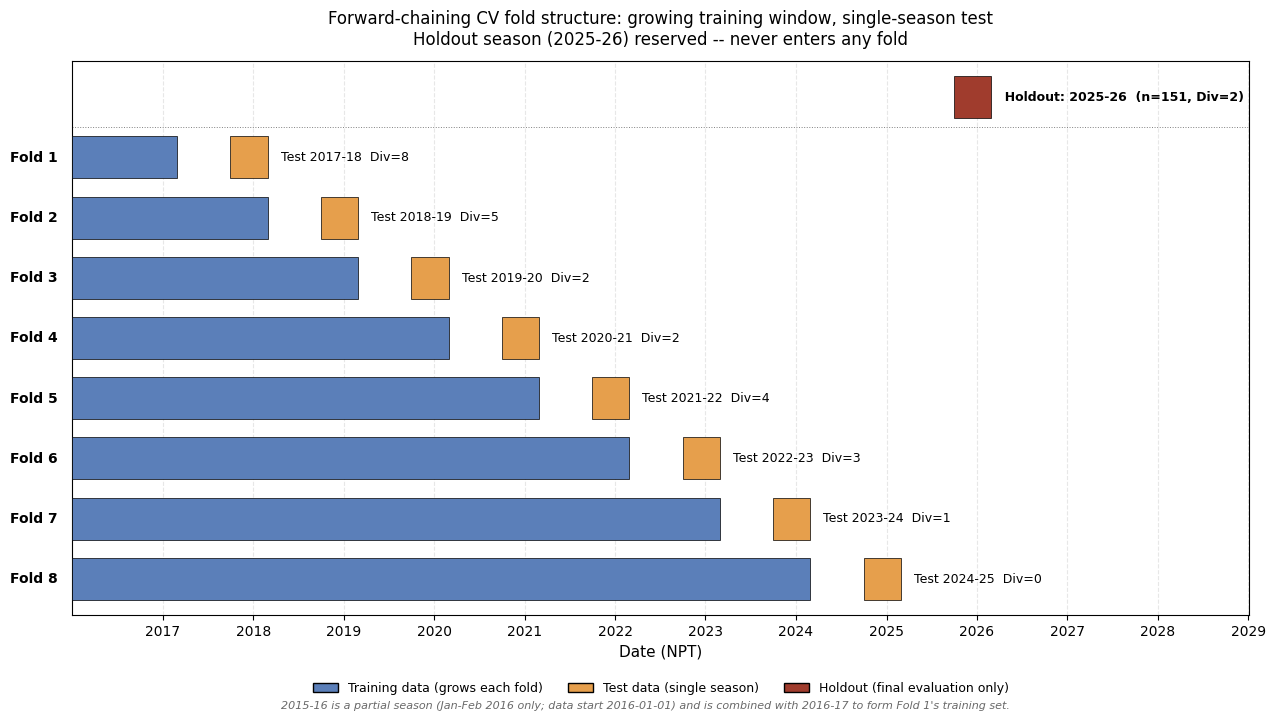

In [7]:
COL_TRAIN = '#5B7FB9'
COL_TEST = '#E69F4C'
COL_HOLDOUT = '#A03C2D'

fig, ax = plt.subplots(figsize=(13, 7.2))
n_rows = len(folds) + 1
row_height = 0.7

# Holdout row at top
y_holdout = n_rows - 1
holdout_start = holdout['date_npt'].min()
holdout_end = holdout['date_npt'].max()
holdout_div = int((holdout[TARGET_CLASSIFICATION] == 2).sum())
ax.barh(y=y_holdout, width=(holdout_end - holdout_start).days, left=holdout_start,
        height=row_height, color=COL_HOLDOUT, edgecolor='black', linewidth=0.5, zorder=3)
ax.text(holdout_end + pd.Timedelta(days=20), y_holdout,
        f'  Holdout: {HOLDOUT_SEASON}  (n={len(holdout)}, Div={holdout_div})',
        va='center', ha='left', fontsize=9, fontweight='bold')

# Fold rows
for i, fold in enumerate(folds):
    y = len(folds) - 1 - i
    ax.barh(y=y, width=(fold.train_end - fold.train_start).days, left=fold.train_start,
            height=row_height, color=COL_TRAIN, edgecolor='black', linewidth=0.5, zorder=3)
    ax.barh(y=y, width=(fold.test_end - fold.test_start).days, left=fold.test_start,
            height=row_height, color=COL_TEST, edgecolor='black', linewidth=0.5, zorder=3)
    test_div = int((train_pool.loc[fold.test_idx, TARGET_CLASSIFICATION] == 2).sum())
    ax.text(fold.test_end + pd.Timedelta(days=20), y,
            f'  Test {fold.test_season}  Div={test_div}',
            va='center', ha='left', fontsize=9)
    ax.text(fold.train_start - pd.Timedelta(days=20), y,
            f'Fold {fold.fold_id}  ', va='center', ha='right',
            fontsize=10, fontweight='bold')

ax.set_yticks([])
ax.set_ylim(-0.6, n_rows - 0.4)
ax.set_xlabel('Date (NPT)', fontsize=11)
ax.set_title('Forward-chaining CV fold structure: growing training window, single-season test\n'
             f'Holdout season ({HOLDOUT_SEASON}) reserved -- never enters any fold',
             fontsize=12, pad=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='x', alpha=0.3, linestyle='--', zorder=1)
ax.axhline(y=n_rows - 1.5, color='grey', linewidth=0.7, linestyle=':')

legend_elements = [
    Patch(facecolor=COL_TRAIN, edgecolor='black', label='Training data (grows each fold)'),
    Patch(facecolor=COL_TEST, edgecolor='black', label='Test data (single season)'),
    Patch(facecolor=COL_HOLDOUT, edgecolor='black', label='Holdout (final evaluation only)'),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.10),
          ncol=3, frameon=False, fontsize=9)
fig.text(0.5, 0.005,
         "2015-16 is a partial season (Jan-Feb 2016 only; data start 2016-01-01) "
         "and is combined with 2016-17 to form Fold 1's training set.",
         fontsize=8, color='dimgrey', style='italic', va='bottom', ha='center')

xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax + (xmax - xmin) * 0.22)
plt.tight_layout()

fig_path = PROJECT_ROOT / 'reports' / 'figures' / 'step3_fold_structure.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Wrote {fig_path}')
plt.show()

## 6. Per-fold class counts (eyeball the rare-class distribution)

Stacked bars show how many Normal / Delays / Diversions days land in each fold's test set. This is the diagnostic that justifies our "report metrics two ways" plan: Folds 7-8 have ≤1 Diversion in test, so per-fold Diversions metrics for those folds will be unstable. Aggregate out-of-fold metrics (computed across concatenated predictions) will be the headline numbers.

Wrote /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step3_per_fold_class_counts.png


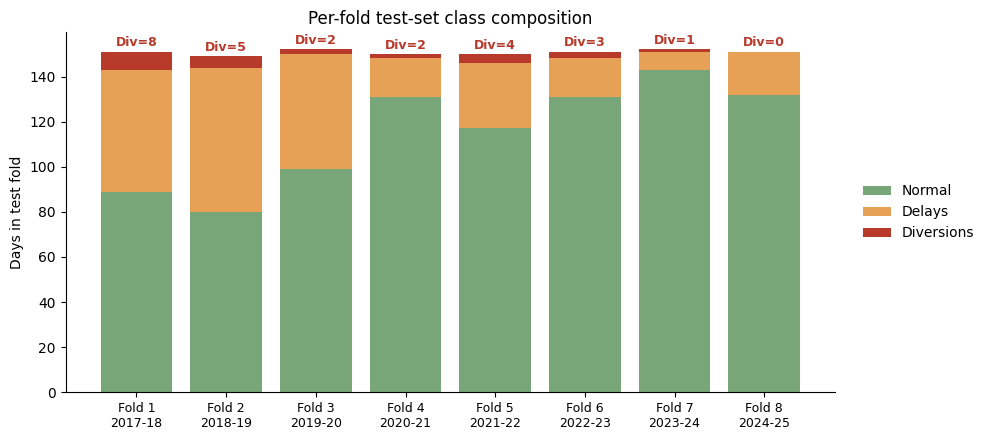

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(folds))
normal = [int((train_pool.loc[f.test_idx, TARGET_CLASSIFICATION]==0).sum()) for f in folds]
delays = [int((train_pool.loc[f.test_idx, TARGET_CLASSIFICATION]==1).sum()) for f in folds]
divs   = [int((train_pool.loc[f.test_idx, TARGET_CLASSIFICATION]==2).sum()) for f in folds]

ax.bar(x, normal, color='#78A678', label='Normal')
ax.bar(x, delays, bottom=normal, color='#E6A157', label='Delays')
ax.bar(x, divs, bottom=np.array(normal)+np.array(delays), color='#B73A2B', label='Diversions')

for i, d in enumerate(divs):
    ax.text(i, normal[i] + delays[i] + d + 1, f'Div={d}',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color='#B73A2B')

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {f.fold_id}\n{f.test_season}' for f in folds], fontsize=9)
ax.set_ylabel('Days in test fold')
ax.set_title('Per-fold test-set class composition')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

fig_path = PROJECT_ROOT / 'reports' / 'figures' / 'step3_per_fold_class_counts.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Wrote {fig_path}')
plt.show()

## 7. Constant-feature diagnostic (per fold)

Surface which features (if any) carry zero variance within each fold's training window. Expected finding on this dataset: `night_fog_observed` is constant in Fold 1 because METAR FG codes are too rare to appear in the 18:00-05:00 NPT window across the 2015-16 (partial) + 2016-17 training pool. From Fold 2 onwards the column gains variance and behaves normally. This is a property of the data, not a problem to fix: both RF and GP-ARD will deweight a feature with no signal.

In [9]:
rows = []
for prepared in iter_prepared_folds(train_pool):
    const = find_constant_features(prepared.X_train)
    rows.append({
        'fold': prepared.spec.fold_id,
        'test_season': prepared.spec.test_season,
        'train_n': prepared.X_train.shape[0],
        'n_constant': len(const),
        'constant_features': ', '.join(const) if const else '(none)',
    })
constant_df = pd.DataFrame(rows)
constant_df

[20:31:33] INFO  Built 8 forward-chaining folds


,fold,test_season,train_n,n_constant,constant_features
0,1,2017-18,204,1,night_clear_fraction
1,2,2018-19,355,0,(none)
2,3,2019-20,504,0,(none)
3,4,2020-21,656,0,(none)
4,5,2021-22,806,0,(none)
5,6,2022-23,956,0,(none)
6,7,2023-24,1107,0,(none)
7,8,2024-25,1259,0,(none)


## Step 3 outputs

- `scripts/cv_splits.py` — CV split / impute / scale logic, importable by downstream steps
- `data/processed/cv_manifest.json` — audit record of all splits
- `reports/figures/step3_fold_structure.png` — Gantt-style fold structure for the paper
- `reports/figures/step3_per_fold_class_counts.png` — per-fold test-set class composition

**Next step:** Step 4 — Baseline Random Forest, consuming `iter_prepared_folds(train_pool)`.